In [1]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)
import pickle

import random
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'pdf.fonttype':42}) 

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/home2/s223695/.local/lib/python3.12/site-packages', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]


numpy 1.26.4
pandas 2.2.1
scipy 1.15.3
matplotlib 3.8.3


### Load disease gene data  

In [2]:
CHD_genes_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/OpenTarget/CHD_Yang/chdgene_table.csv', sep=',')

In [3]:
CHD_gene_name = CHD_genes_df["Gene"].values

In [4]:
CHD_gene_name.shape

(142,)

### Load e-distance hits

In [5]:
pval_hit_path = "/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_052924/p_val_gRNA_sig_full_expressing_v3.csv"
pval_hit_df = pd.read_csv(pval_hit_path,index_col=0)

sig_tf_list = pval_hit_df["gene_name"].unique()

### Load pySpade data

In [6]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [7]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [8]:
global_df["Pert_name"] = global_df["region"].apply(lambda x: annot_dict[x])

In [9]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

### confirm the regulation with TF motif
* use bedtool intersect on terminal

In [10]:
TF_motif_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/TF_motif/All_DE_motif/All_DEgenes_TFmotif.txt'

In [11]:
cols = [
    "rechr", "restart", "reend", "gene",
    "chr", "start", "end", "motif", "pos", "strand",
    "TF", "overlap"
]

TF_motif_small = pd.read_csv(
    TF_motif_file,
    sep="\t",
    header=None,
    names=cols,
    usecols=["gene", "TF", "overlap"],
    dtype={"overlap": "int32"},
    memory_map=True,
)

pairs = TF_motif_small.loc[
    TF_motif_small["overlap"].to_numpy() > 5,
    ["TF", "gene"]
].copy()

pairs["TF"] = pairs["TF"].str.upper()

pairs = pairs.drop_duplicates(["TF", "gene"], ignore_index=True)

motif_target_dict = {
    tf: genes.to_numpy(copy=False)
    for tf, genes in pairs.groupby("TF", sort=False)["gene"]
}

### Find out any targeted TFs that are CHD genes

In [12]:
CHD_TF = list(set(TF_region_df['TF'].values).intersection(CHD_genes_df['Gene']))

In [13]:
len(CHD_TF)

50

In [14]:
CHD_TF_region = list(TF_region_df[TF_region_df['TF'].isin(CHD_TF)].index)

In [15]:
gene_counts = global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].value_counts()
duplicate_genes = gene_counts[gene_counts > 4].index
CHD_TF_global_df = global_df[global_df['region'].isin(CHD_TF_region)][global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].isin(duplicate_genes)]

### Stat for out-degree node of TFs

In [16]:
target_region_list = np.unique(global_df["region"])

In [17]:
deg_num_list = []
for target_region in tqdm(target_region_list):
    primary_gene = annot_dict[target_region]
    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))
    deg_num_list.append(len(secondary_target_list))

  0%|          | 0/2082 [00:00<?, ?it/s]

  3%|▎         | 69/2082 [00:00<00:02, 680.87it/s]

  7%|▋         | 138/2082 [00:00<00:02, 672.94it/s]

 10%|▉         | 207/2082 [00:00<00:02, 678.33it/s]

 13%|█▎        | 275/2082 [00:00<00:02, 678.33it/s]

...

 89%|████████▉ | 1849/2082 [00:02<00:00, 678.68it/s]

 92%|█████████▏| 1917/2082 [00:02<00:00, 677.59it/s]

 95%|█████████▌| 1985/2082 [00:02<00:00, 677.26it/s]

 99%|█████████▊| 2054/2082 [00:03<00:00, 679.01it/s]

100%|██████████| 2082/2082 [00:03<00:00, 678.03it/s]

In [18]:
secondary_target_list

['VPS16', 'CEP290', 'BCKDHB', 'RABEPK', 'FCMR']

In [19]:
primary_gene

'TGIF2LY'

In [20]:
deg_num, count_num = np.unique(deg_num_list,return_counts=True)

Text(0, 0.5, 'Log10(Count of TFs)')

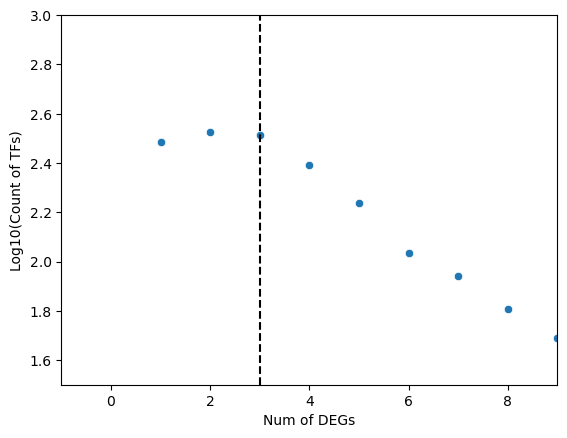

In [21]:
fig,ax = plt.subplots()
sns.scatterplot(x=deg_num, y=np.log10(count_num))
ax.axvline(3,c="black",linestyle="--")
ax.set_xlim(-1,9)
ax.set_ylim(1.5,3)
ax.set_xlabel("Num of DEGs")
ax.set_ylabel("Log10(Count of TFs)")

### Generate the gene regulatory networks

In [22]:
global_df

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684,NCOA1
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529,NCOA1
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946,NCOA1
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569,NCOA1
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102,NCOA1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27573,31558319,38228,FITM1,chr14,2215538585,+,1,13,chrX:49042845-49043845,794,750,-12.332692,1.287023,-13.735282,1.285053,0.0,135.824176,105.693160,TFE3
27574,31559427,47101,PECAM1,chr17,2555194338,-,0,16,chrX:49042845-49043845,794,750,-9.699542,16.178142,-11.238323,14.979639,0.0,3.247754,0.207479,TFE3
27575,31579300,28022,DPP7,chr9,1673604089,-,0,8,chr19:52527153-52528153,811,750,-19.835936,0.714110,-19.482662,0.715293,0.0,186.828915,261.196259,ZNF808
27576,31582291,51353,ZNF808,chr19,2706938940,+,0,18,chr19:52527153-52528153,811,750,-18.799928,0.471482,-18.062261,0.474419,0.0,17.071369,35.994817,ZNF808


In [23]:
target_region_list = np.unique(global_df["region"])

In [24]:
min_regulating_gene = 3

G = nx.DiGraph()

valid_tf_region_list = []
local_hit_list = []
global_hit_list = []
skip_list = []
deg_num_list = []

for target_region in tqdm(target_region_list):
    primary_gene = annot_dict[target_region]
    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))

    if (re.search("^OR[0-9]",primary_gene) != None) or \
       (primary_gene == 'NonTarget'):
        skip_list.append(primary_gene)
        continue

    if (len(secondary_target_list) < min_regulating_gene):
        skip_list.append(primary_gene)
        continue
    valid_tf_region_list.append(target_region)
    G.add_node(primary_gene, type='TF', color=0, subset=0) 

print("Valid TFs",len(list(G.nodes())))

for target_region in tqdm(valid_tf_region_list):
    primary_gene = annot_dict[target_region]

    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))
    secondary_fc_list = list(set(global_df[global_df['region'] == target_region]["fc_by_rand_dist_cpm"].values))
    deg_num_list.append(len(secondary_target_list))
    for secondary_target,secondary_fc in zip(secondary_target_list,secondary_fc_list):
        global_hit_list.append(secondary_target)
        if not secondary_target in list(G.nodes()):
            G.add_node(secondary_target, type='gene', color=1, subset=2)
        
        if (primary_gene == secondary_target):
            continue
        if secondary_fc > 1:
            G.add_edge(primary_gene, secondary_target, regulation='up_regualte')
        else:
            G.add_edge(primary_gene, secondary_target, regulation='down_regualte')


  0%|          | 0/2082 [00:00<?, ?it/s]

  3%|▎         | 67/2082 [00:00<00:03, 665.87it/s]

  6%|▋         | 135/2082 [00:00<00:02, 671.93it/s]

 10%|▉         | 203/2082 [00:00<00:02, 673.72it/s]

 13%|█▎        | 271/2082 [00:00<00:02, 674.71it/s]

...

 94%|█████████▎| 1309/1397 [00:05<00:00, 223.55it/s]

 96%|█████████▌| 1336/1397 [00:05<00:00, 235.96it/s]

 98%|█████████▊| 1363/1397 [00:05<00:00, 244.49it/s]

100%|█████████▉| 1391/1397 [00:05<00:00, 253.87it/s]

100%|██████████| 1397/1397 [00:05<00:00, 246.95it/s]

In [25]:
TF_region_df[TF_region_df["TF"]=="TBX5"]

,TF
chr12:114405669-114406173,TBX5
chr12:114407720-114407979,TBX5


In [26]:
global_df[global_df["region"]=="chr12:114405669-114406173"].head()

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,Pert_name
13117,10456907,5927,SLC8A1,chr2,289567475,-,1,1,chr12:114405669-114406173,279,500,-14.153573,0.780264,-13.742050,0.778913,0.0,1575.097251,2022.176842,TBX5
13118,10456926,6083,NRXN1,chr2,300181997,-,1,1,chr12:114405669-114406173,279,500,-12.331129,0.378570,-11.317575,0.379919,0.0,21.980393,57.871761,TBX5
13119,10457134,7942,KCNH7,chr2,411795152,-,1,1,chr12:114405669-114406173,279,500,-15.415384,0.622149,-14.017528,0.620823,0.0,367.999299,592.766469,TBX5
13120,10457344,9523,PLCL2,chr3,507952602,+,0,2,chr12:114405669-114406173,279,500,-12.295756,0.475812,-11.421372,0.471073,0.0,58.214552,123.589741,TBX5
13121,10457569,11164,TRH,chr3,621124256,+,0,2,chr12:114405669-114406173,279,500,-20.429671,0.363913,-20.450777,0.363011,0.0,61.656285,169.864496,TBX5


In [27]:
for i,gene_list in enumerate(list(nx.weakly_connected_components(G))):
    print(i,len(gene_list))

0 8438
1 3
2 4
3 4
4 4
5 4
6 4
7 3


In [28]:
largest_subgraph_nodes = list(nx.weakly_connected_components(G))[0]
largest_subgraph = G.subgraph(largest_subgraph_nodes).copy()

In [29]:
# remove miscullas graph
G = largest_subgraph

In [30]:
print("Nodes",len(G.nodes()))
print("edges",len(G.edges()))

Nodes 8438
edges 25621


In [31]:
#Annotate with motif

for gene_name in G.nodes():
    if gene_name in motif_target_dict.keys():
        G.nodes[gene_name]["motif_info"]=True
    else:
        G.nodes[gene_name]["motif_info"]=False
        
for g1,g2 in G.edges():
    if g1 in motif_target_dict.keys():
        if g2 in motif_target_dict[g1]:
            G.edges[g1,g2]["is_motif"]=True
            continue
    elif g2 in motif_target_dict.keys():
        if g1 in motif_target_dict[g2]:
            G.edges[g1,g2]["is_motif"]=True
            continue
    G.edges[g1,g2]["is_motif"]=False
        

In [32]:
pickle.dump(G, open('../Data/GRN_base.pickle', 'wb'))

In [33]:
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

### illustrate example network

In [34]:
TF_nodes_keys = ["TBX20","MYOCD","ISL1","MEF2C","NKX2-5"]
target_nodes_keys = ["TNNC1","MYL3","CKM","NPPA"]

G_sub = G.subgraph(np.concatenate([TF_nodes_keys,target_nodes_keys]))

In [35]:
G_sub

/tmp/ipykernel_2926881/2138315473.py:38: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


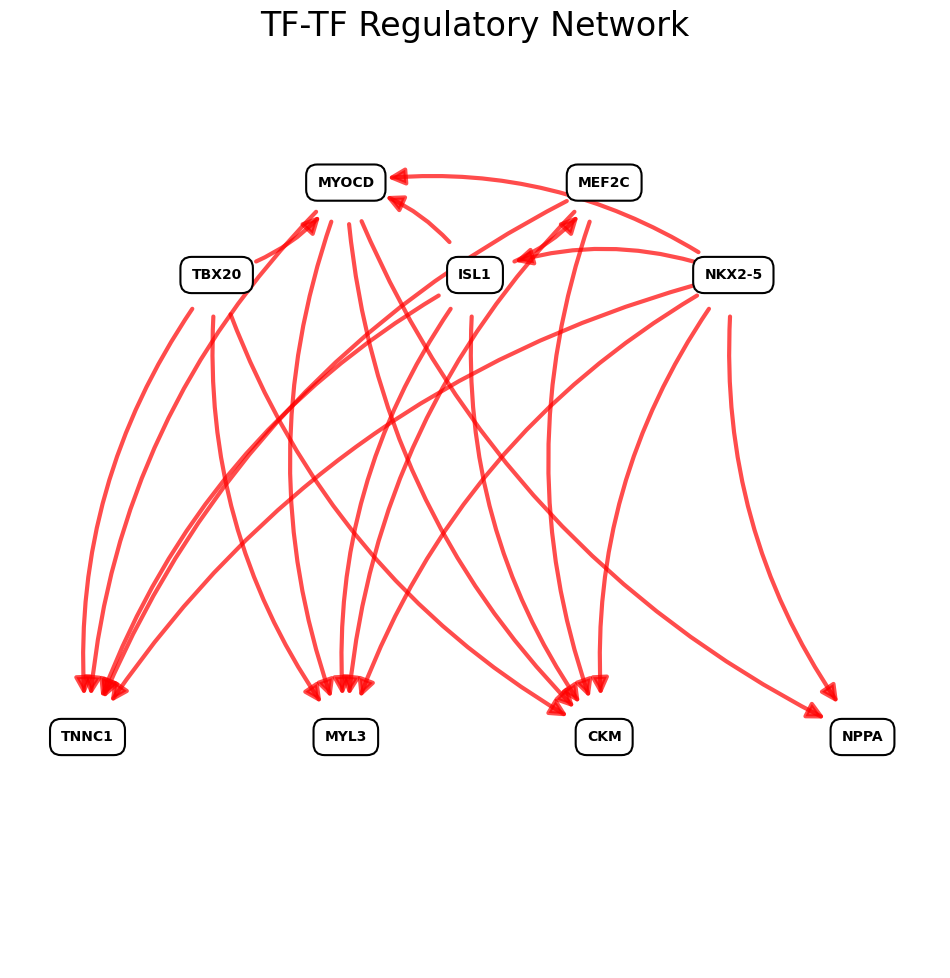

In [36]:
# 1. Layout setup (using the zigzag configuration)
pos = {}

# Place TFs on the top layer with alternating Y positions
tf_x = np.linspace(-1.0, 1.0, len(TF_nodes_keys))
for i, node in enumerate(TF_nodes_keys):
    y_pos = 1.0 if i % 2 == 0 else 1.2
    pos[node] = np.array([tf_x[i], y_pos])
    
# Place Targets on the bottom layer
target_x = np.linspace(-1.5, 1.5, len(target_nodes_keys))
for i, node in enumerate(target_nodes_keys):
    pos[node] = np.array([target_x[i], 0.0])

# 2. Determine edge styles (Colors AND Widths)
edge_colors = []
edge_widths = [] # List to store edge widths

for u, v, data in G_sub.edges(data=True):
    # Set edge color
    if data.get("regulation") == "down_regulate":
        base_rgb = (0, 0, 1) # Blue
    else:
        base_rgb = (1, 0, 0) # Red
    edge_colors.append(base_rgb)

    # Set edge width: Thicker if both source and target are TFs
    if u in TF_nodes_keys and v in TF_nodes_keys:
        edge_widths.append(3.0) # Thick line for TF-TF regulation
    else:
        edge_widths.append(3.0) # Standard line for TF-Target regulation

# Plot setup
plt.figure(figsize=(12, 12)) 
ax = plt.gca()

# 3. Draw edges with dynamic widths
nx.draw_networkx_edges(
    G_sub,
    pos,
    edge_color=edge_colors,
    width=edge_widths, # Apply the width list here
    arrows=True,
    arrowsize=25, 
    connectionstyle="arc3,rad=0.2", 
    min_source_margin=30, 
    min_target_margin=30, 
    alpha=0.7 
)

# 4. Draw nodes
for node in G_sub.nodes():
    x, y = pos[node]

    box_lw = 1.5
    font_weight = 'bold'
    box_color = "black"

    ax.text(
        x, y, node,
        fontsize=10, 
        fontweight=font_weight,
        horizontalalignment='center',
        verticalalignment='center',
        bbox=dict(
            boxstyle="round,pad=0.8", 
            fc="white",
            ec=box_color,
            lw=box_lw,
            alpha=1.0 
        ),
        zorder=10
    )

# Adjust axes limits
plt.xlim(-1.8, 1.8)
plt.ylim(-0.5, 1.5)
plt.axis("off")

# Title
plt.title("TF-TF Regulatory Network", fontsize=24)
plt.savefig("../Plot/example_network.pdf")
plt.show()

### Analyze directed property on TF-TF network

In [37]:
def extract_TF_TF_graph(G):
    TF_node_list = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
    TF_TF_network = G.subgraph(TF_node_list).copy()
    
    components = list(nx.weakly_connected_components(TF_TF_network))
    largest_component = max(components, key=len)
    TF_TF_sg = G.subgraph(largest_component).copy()
    
    return TF_TF_sg

In [38]:
TF_TF_rand_network = extract_TF_TF_graph(G)
print("Node:",len(TF_TF_rand_network.nodes))
print("Edge:",len(TF_TF_rand_network.edges))

Node: 716
Edge: 1536


In [39]:
in_degrees = dict(TF_TF_rand_network.in_degree())
out_degrees = dict(TF_TF_rand_network.out_degree())

in_degree_values = list(in_degrees.values())
out_degree_values = list(out_degrees.values())

in_degree_max = max(in_degree_values)
out_degree_max = max(out_degree_values)

In [40]:
in_degree_df = pd.DataFrame(in_degrees.values(),index=in_degrees.keys(),columns=["Count"])
out_degree_df = pd.DataFrame(out_degrees.values(),index=out_degrees.keys(),columns=["Count"])

In [41]:
out_degree_df.sort_values("Count",ascending=False)

,Count
ISL1,91
TBX20,62
TADA2B,57
SOX11,56
RCOR2,54
...,...
ZBED1,0
LIN28A,0
HMGXB4,0
OTX2,0


In [42]:
in_degrees["ZNF441"]

0

<Axes: ylabel='Count'>

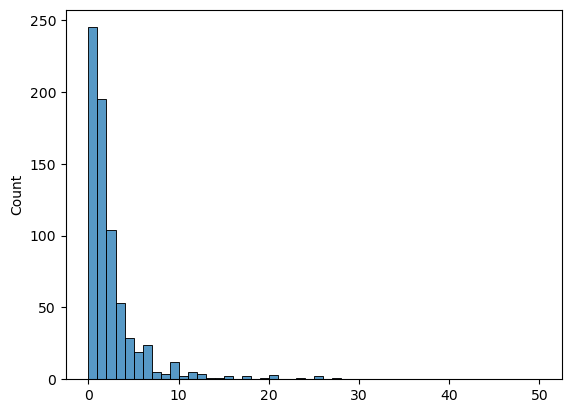

In [43]:
sns.histplot(in_degree_values,bins=range(in_degree_max))

<Axes: ylabel='Count'>

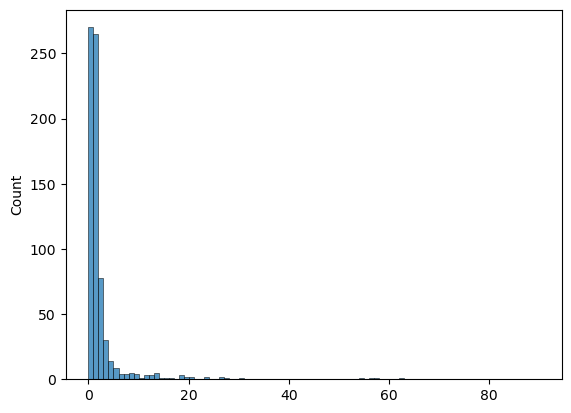

In [44]:
sns.histplot(out_degree_values,bins=range(out_degree_max))

In [45]:
G.edges("ZNF441")

OutEdgeDataView([('ZNF441', 'CPVL'), ('ZNF441', 'SMIM20'), ('ZNF441', 'MRPL2'), ('ZNF441', 'MAPKAPK5'), ('ZNF441', 'ANAPC13'), ('ZNF441', 'FBL'), ('ZNF441', 'MRPS12'), ('ZNF441', 'SOX11'), ('ZNF441', 'CLDND1'), ('ZNF441', 'PARG'), ('ZNF441', 'SNX24'), ('ZNF441', 'UBAC1')])

### Analyze TF-TF network

In [46]:
node_list = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
node_list = [node for node in node_list if node != "Positve control"]
Between_TF_network = G.subgraph(node_list).copy()

print(len(Between_TF_network.nodes))
print(len(Between_TF_network.edges))
between_TF_prb = nx.density(Between_TF_network)
print(between_TF_prb)

1315
1585
0.0009172931460550607


### Analyze Hierarchical feature

In [47]:
DEG_num_sr = global_df.groupby("Pert_name")["gene_names"].apply(len)

In [48]:
# Hiearachy height h = (O-I)/(O+I)
# Focusing within significant hits in e-distance

sif_TF_network = Between_TF_network.subgraph(sig_tf_list)
print(len(sif_TF_network.edges()))

hierarchy_height_dict = {}

for node in sif_TF_network.nodes:
    O = Between_TF_network.out_degree(node)
    I = Between_TF_network.in_degree(node)
    if O + I < 5:
        continue
    hierarchy_height_dict[node] = {}
    hierarchy_height_dict[node]["hierarchy_height"] = (O - I) / (O + I)
    hierarchy_height_dict[node]["out_degree"] = O 
    hierarchy_height_dict[node]["in_degree"] = I 
    hierarchy_height_dict[node]["total_deg"] = DEG_num_sr[node]
    hierarchy_height_dict[node]["is_CHD_TF"] = node in CHD_gene_name
print(len(hierarchy_height_dict.keys()))

313
83


In [49]:
hierarchy_height_df = pd.DataFrame(hierarchy_height_dict).T
hierarchy_height_df = hierarchy_height_df.sort_values("hierarchy_height",ascending=True)
hierarchy_height_df.to_csv("../output_data/hierarchy_height.csv")

In [50]:
hierarchy_height_df.sort_values("hierarchy_height",ascending=True).iloc[:5]

,hierarchy_height,out_degree,in_degree,total_deg,is_CHD_TF
IRX2,-1.0,0,5,12,False
FOS,-1.0,0,19,19,False
NKX2-3,-1.0,0,6,6,False
NR3C1,-1.0,0,5,11,False
ETS1,-1.0,0,6,10,False


### Analyzing gnomeAD data

In [51]:
gnomad_url = "https://storage.googleapis.com/gcp-public-data--gnomad/release/4.1/constraint/gnomad.v4.1.constraint_metrics.tsv"
gnomad_df = pd.read_csv(gnomad_url,sep="\t")

In [52]:
gnomad_df_clean = gnomad_df[(~gnomad_df["gene"].isna()) & \
                            (gnomad_df["gene_id"].apply(lambda x: x.startswith("ENSG"))) & \
                            (gnomad_df["canonical"] | gnomad_df["mane_select"])]
gnomad_df_clean = gnomad_df_clean.set_index("gene")

In [53]:
gnomad_df_clean.columns

Index(['gene_id', 'transcript', 'canonical', 'mane_select', 'lof_hc_lc.obs',
       'lof_hc_lc.exp', 'lof_hc_lc.possible', 'lof_hc_lc.oe', 'lof_hc_lc.mu',
       'lof_hc_lc.pLI', 'lof_hc_lc.pNull', 'lof_hc_lc.pRec', 'lof.obs',
       'lof.exp', 'lof.possible', 'lof.oe', 'lof.mu', 'lof.pLI', 'lof.pNull',
       'lof.pRec', 'lof.oe_ci.lower', 'lof.oe_ci.upper',
       'lof.oe_ci.upper_rank', 'lof.oe_ci.upper_bin_decile', 'lof.z_raw',
       'lof.z_score', 'mis.obs', 'mis.exp', 'mis.possible', 'mis.oe', 'mis.mu',
       'mis.oe_ci.lower', 'mis.oe_ci.upper', 'mis.z_raw', 'mis.z_score',
       'mis_pphen.obs', 'mis_pphen.exp', 'mis_pphen.possible', 'mis_pphen.oe',
       'syn.obs', 'syn.exp', 'syn.possible', 'syn.oe', 'syn.mu',
       'syn.oe_ci.lower', 'syn.oe_ci.upper', 'syn.z_raw', 'syn.z_score',
       'constraint_flags', 'level', 'transcript_type', 'chromosome',
       'cds_length', 'num_coding_exons'],
      dtype='object')

In [54]:
#LOEUF = lof.oe_ci.upper
loeuf_dict = gnomad_df_clean["lof.oe_ci.upper"].to_dict()

In [55]:
hierarchy_height_df["LOEUF"] = hierarchy_height_df.index.map(lambda x: loeuf_dict.get(x,None))

In [56]:
hierarchy_height_df.sort_values("total_deg",ascending=False).iloc[:30]

,hierarchy_height,out_degree,in_degree,total_deg,is_CHD_TF,LOEUF
ISL1,0.895833,91,5,1275,False,0.235
TADA2B,1.0,57,0,950,False,0.758
SOX11,0.964912,56,1,942,False,1.148
RCOR2,0.928571,54,2,864,False,0.539
TBX20,0.878788,62,4,754,True,0.378
HAND1,0.333333,30,15,469,True,1.188
SOX4,0.8,27,3,435,False,0.720
HIF1A,0.916667,23,1,431,False,0.353
NKX2-5,0.0,20,20,372,True,0.321
PITX2,0.533333,23,7,364,True,0.410


In [57]:
hierarchy_height_df.dropna()["hierarchy_height"].values.shape

(81,)

In [58]:
np.corrcoef(hierarchy_height_df.dropna()["hierarchy_height"].astype(float).values,
            hierarchy_height_df.dropna()["LOEUF"].values
           )

array([[1.        , 0.07777523],
       [0.07777523, 1.        ]])

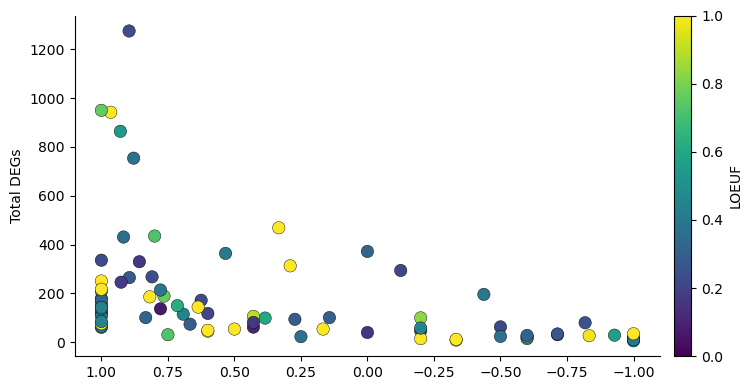

In [59]:
fig,ax = plt.subplots(figsize=(8,4), dpi=100)

norm = Normalize(0, 1, clip=True)

# ---- Scatter ----
scatter = sns.scatterplot(
    data=hierarchy_height_df.dropna(),
    x="hierarchy_height",
    y="total_deg",
    hue="LOEUF",
    palette="viridis",        # Highly recommended
    hue_norm=norm,
    edgecolor="black",
    linewidth=0.3,           # Better than thick edges
    s=80,
    legend=False,            # Remove legend
    ax=ax
)

ax.set_ylabel("Total DEGs")
ax.set_xlabel("")

# ---- Colorbar ----
sm = cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("LOEUF")

ax.invert_xaxis()

# Clean look
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("../Plot/hierarchy_DEG_LOEUF.pdf")
plt.show()


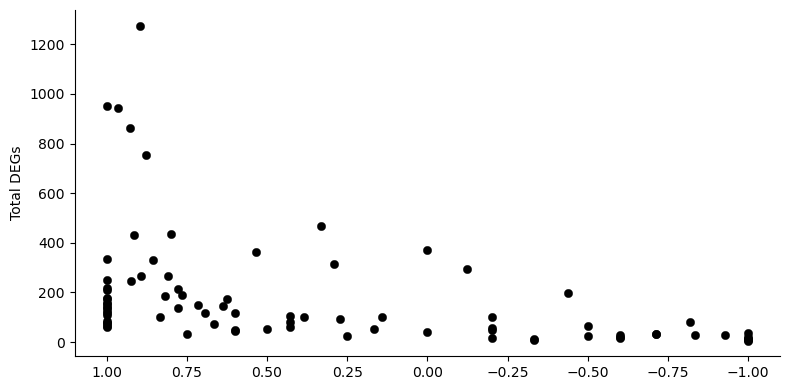

In [60]:
fig,ax = plt.subplots(figsize=(8,4), dpi=100)

norm = Normalize(0, 1, clip=True)

# ---- Scatter ----
scatter = sns.scatterplot(
    data=hierarchy_height_df.dropna(),
    x="hierarchy_height",
    y="total_deg",
    hue_norm=norm,
    edgecolor="black",
    linewidth=0.3,           # Better than thick edges
    c="black",
    legend=False,            # Remove legend
    ax=ax
)

ax.set_ylabel("Total DEGs")
ax.set_xlabel("")

ax.invert_xaxis()

# Clean look
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("../Plot/hierarchy_simple.pdf")
plt.show()


In [61]:
hierarchy_height_df.to_csv("../output_data/hierarchy_height.csv")

<Axes: xlabel='hierarchy_height', ylabel='Count'>

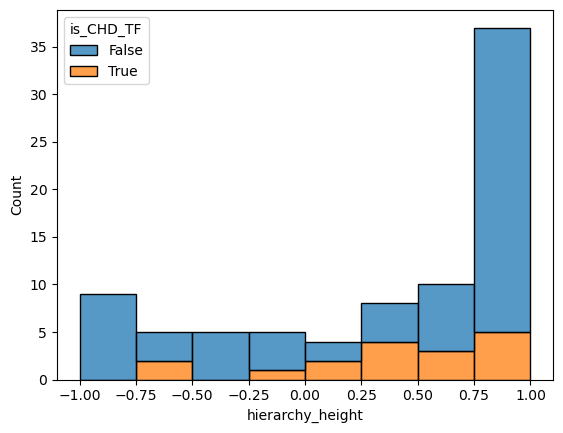

In [62]:
sns.histplot(hierarchy_height_df,x="hierarchy_height",hue="is_CHD_TF", multiple="stack")

In [63]:
hierarchy_height_df

,hierarchy_height,out_degree,in_degree,total_deg,is_CHD_TF,LOEUF
IRX2,-1.0,0,5,12,False,1.305
FOS,-1.0,0,19,19,False,0.581
NKX2-3,-1.0,0,6,6,False,0.561
NR3C1,-1.0,0,5,11,False,0.294
ETS1,-1.0,0,6,10,False,0.393
...,...,...,...,...,...,...
GATAD1,1.0,6,0,76,False,1.789
ZNF532,1.0,8,0,174,False,0.307
ZFP64,1.0,11,0,143,False,0.436
PCGF2,1.0,9,0,85,False,0.443


### Apply reverse Page rank

In [64]:
up_edges =   [(u, v) for u, v, attributes in G.edges(data=True) 
              if attributes.get('regulation') == 'up_regualte']
down_edges = [(u, v) for u, v, attributes in G.edges(data=True) 
              if attributes.get('regulation') == 'down_regualte']

In [65]:
G_up   = G.edge_subgraph(up_edges)
G_down = G.edge_subgraph(down_edges)

In [66]:
print(len(list(G_down.nodes)))
print(len(list(G_up.nodes)))

3399
7837


In [67]:
weight_dict = {}
for node in G.nodes():
    if (node in CHD_gene_name) and (not node in TF_nodes):
        print
        weight_dict[node] = 1.0
    else:
        weight_dict[node] = 0.0

# Normalization
total = sum(weight_dict.values())
if total > 0:
    for node in weight_dict:
        weight_dict[node] /= total

In [68]:
weight_dict["TBX20"]

0.0

In [69]:
reversed_G = G.reverse(copy=True)
pr_res_total = nx.pagerank(reversed_G,alpha=0.85,personalization=weight_dict)
pr_res_df_total = pd.DataFrame(pr_res_total.values(),index=pr_res_total.keys(),columns=["importance"])
pr_res_df_total = pr_res_df_total.sort_values("importance",ascending=False)

In [70]:
pr_res_df_total.head(20)

,importance
ISL1,0.029494
SOX11,0.019758
TBX20,0.018863
ARNT,0.017340
ZNF441,0.016752
NKX2-5,0.015038
ZFPM2,0.014896
TADA2B,0.014752
RCOR2,0.013033
ZFPM1,0.012532


In [71]:
pr_res_df_total.loc["TBX5"]

importance    0.000219
Name: TBX5, dtype: float64

In [72]:
pr_res_df_total.index[:20]

Index(['ISL1', 'SOX11', 'TBX20', 'ARNT', 'ZNF441', 'NKX2-5', 'ZFPM2', 'TADA2B',
       'RCOR2', 'ZFPM1', 'ARID2', 'SOX4', 'CRAMP1L', 'PITX2', 'PLAGL2',
       'HAND1', 'ZFP90', 'HOXB4', 'SMAD5', 'LCOR'],
      dtype='object')

#### Only focus on upregulation

In [73]:
reversed_G_up = G_up.reverse(copy=True)
pr_res_up = nx.pagerank(reversed_G_up,alpha=0.85,personalization=weight_dict)
pr_res_df_up = pd.DataFrame(pr_res_up.values(),index=pr_res_up.keys(),columns=["importance"])
pr_res_df_up = pr_res_df_up.sort_values("importance",ascending=False)

In [74]:
pr_res_df_up.head(10)

,importance
ISL1,0.034921
SOX11,0.021534
ZNF441,0.018361
ZFPM2,0.016872
RCOR2,0.016864
ZFPM1,0.014447
ARNT,0.013999
TADA2B,0.013741
LCOR,0.011844
ARID2,0.011603


#### Only focus on downregulation

In [75]:
reversed_G_down = G_down.reverse(copy=True)
pr_res_down = nx.pagerank(reversed_G_down,alpha=0.85,personalization=weight_dict)
pr_res_df_down = pd.DataFrame(pr_res_down.values(),index=pr_res_down.keys(),columns=["importance"])
pr_res_df_down = pr_res_df_down.sort_values("importance",ascending=False)

In [76]:
pr_res_df_down.head(10)

,importance
NKX2-5,0.045422
TBX20,0.041674
SOX4,0.030870
ISL1,0.021836
MEIS1,0.020993
HIF1A,0.018634
MYH7,0.018111
MEIS2,0.018111
BCOR,0.018111
ACVR1,0.018111


#### plot pagerank feature

In [77]:
pr_res_df_total_TF = pr_res_df_total[np.isin(pr_res_df_total.index,TF_nodes)]

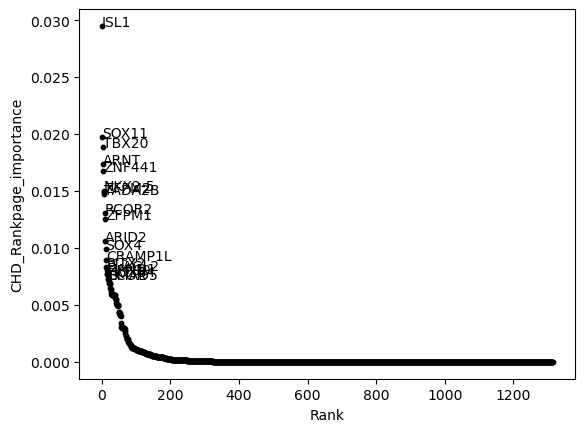

In [78]:
rank = list(range(pr_res_df_total_TF.shape[0]))
value = pr_res_df_total_TF["importance"].values
plt.scatter(rank,value,s=10,c="black",marker="o")
plt.xlabel("Rank")
plt.ylabel("CHD_Rankpage_importance")

for i in range(20):
    plt.text(rank[i],value[i],pr_res_df_total.index[i])
    
plt.savefig("../Plot/CHD_pagerank_importance.pdf")

In [79]:
print(len(G.nodes))
print(len(G.edges))

8438
25621


### CHD regulator TF_enrichment

In [80]:
NonTF_CHD_genes = set(CHD_genes_df['Gene']).difference(set(TF_region_df['TF'].values))

In [81]:
regulator_dict = {}
count_dict = {}

for gene in NonTF_CHD_genes:
    if gene in G.nodes():
        regulator = np.unique(list(G.predecessors(gene)))
        regulator_dict[gene] = regulator
        count_dict[gene] = len(regulator)

In [82]:
all_regulator = np.unique(np.concatenate(list(regulator_dict.values())))

downstream_CHD_dict = {}
downstream_CHD_count_dict = {}

for tf in all_regulator:
    downstream_CHD_dict[tf] = {"up":[],
                               "down":[]}
    
    ds_gene = list(G.successors(tf))
    ds_gene = list(set(ds_gene) & set(CHD_genes_df['Gene']))
    for gene in ds_gene:
        if G[tf][gene]["regulation"]=="up_regualte":
            downstream_CHD_dict[tf]["up"].append(gene)
        else:
            downstream_CHD_dict[tf]["down"].append(gene)
    downstream_CHD_count_dict[tf] = {"total":[],"up":[],"down":[]}
    downstream_CHD_count_dict[tf]["up"] = len(downstream_CHD_dict[tf]["up"])
    downstream_CHD_count_dict[tf]["down"] = len(downstream_CHD_dict[tf]["down"])
    downstream_CHD_count_dict[tf]["total"] = downstream_CHD_count_dict[tf]["up"] + \
                                             downstream_CHD_count_dict[tf]["down"]

In [83]:
downstream_CHD_df = pd.DataFrame(downstream_CHD_count_dict).T

In [84]:
downstream_CHD_df = downstream_CHD_df.sort_values("total",ascending=False)

In [85]:
top20_chd_regulating_tf = list(downstream_CHD_df.index[:20])

In [86]:
top20_chd_regulating_tf

['ISL1',
 'TBX20',
 'SOX11',
 'RCOR2',
 'NKX2-5',
 'SMAD5',
 'HOXB4',
 'TADA2B',
 'HAND1',
 'PITX2',
 'ZFPM2',
 'SMAD6',
 'MEF2C',
 'ARID2',
 'MEIS1',
 'SOX4',
 'TCF7',
 'ZBTB10',
 'ZNF532',
 'ZNF20']

In [87]:
set(top20_chd_regulating_tf) & set(CHD_genes_df['Gene'])

{'HAND1', 'NKX2-5', 'PITX2', 'SMAD6', 'TBX20', 'ZFPM2'}

In [88]:
downstream_CHD_df_melt=downstream_CHD_df.head(20).melt(ignore_index=False).reset_index()

In [89]:
downstream_CHD_df_melt.head()

,index,variable,value
0,ISL1,total,20
1,TBX20,total,18
2,SOX11,total,15
3,RCOR2,total,14
4,NKX2-5,total,12


In [90]:
count_df = pd.DataFrame(count_dict.values(),index=count_dict.keys(),columns=["count"])
count_df = count_df.sort_values("count",ascending=False)

In [91]:
print(count_df.shape)
print(np.mean(count_df))

(50, 1)
7.36


In [92]:
count_df_sub = count_df.head(10)

In [93]:
count_df_sub

,count
MYH7,71
MYH6,51
KDR,46
ACTC1,42
GPC3,27
MYBPC3,21
CITED2,9
FBN1,9
TAB2,7
GJA1,6


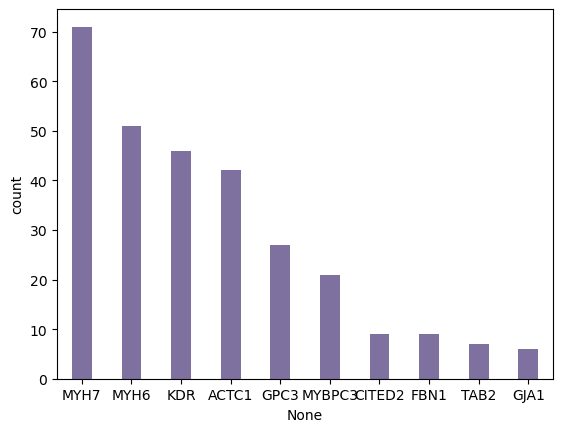

In [94]:
sns.barplot(x=count_df_sub.index,y=count_df_sub["count"],color="#7B69A7",width=0.4)
plt.savefig("../Plot/CHD_regulated_num.pdf")

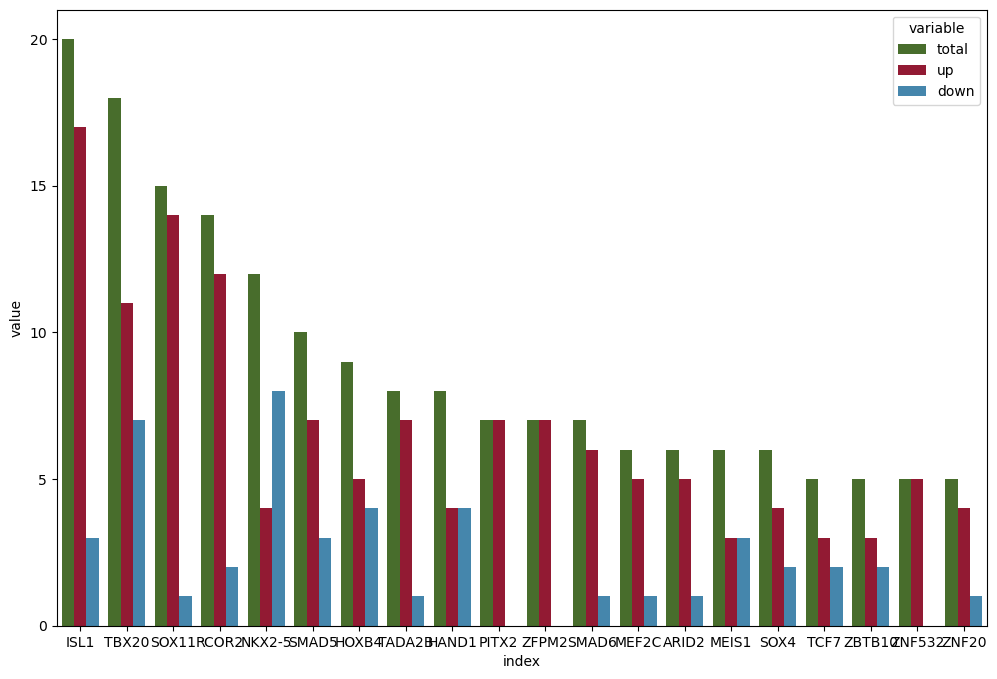

In [95]:
barWidth = 0.25
fig,ax = plt.subplots(figsize =(12, 8)) 
sns.barplot(downstream_CHD_df_melt,
            x="index",y="value",hue="variable",color="#7B69A7",width=0.8,
            palette=["#467821","#A60628","#348ABD"]
           )
plt.yticks([0,5,10,15,20])

plt.savefig("../Plot/CHD_DE_num.pdf")

In [96]:
downstream_CHD_df

,total,up,down
ISL1,20,17,3
TBX20,18,11,7
SOX11,15,14,1
RCOR2,14,12,2
NKX2-5,12,4,8
...,...,...,...
BBX,1,1,0
BHLHA15,1,1,0
BNC1,1,1,0
CAMTA2,1,1,0


### Visualize TF-network

In [97]:
NonTF_CHD_genes = set(CHD_genes_df['Gene']).difference(set(TF_region_df['TF'].values))

In [98]:
print(len(NonTF_CHD_genes))

92


In [100]:
for u, v in G.edges():
    if G.edges[u,v]["is_motif"]:
        G[u][v]["weight"]=3
    else:
        G[u][v]["weight"]=1

#### extract non-TF CHD + regulator

In [101]:
node_list = []
for gene in NonTF_CHD_genes:
    if gene in G.nodes():
        node_list.append([gene])
        node_list.append(list(G.predecessors(gene)))

node_list = np.unique(np.concatenate(node_list))

In [102]:
len(node_list)

260

In [103]:
G_non_tf_chd = G.subgraph(node_list).copy()

In [104]:
TF_nodes_chd = [node for node, data in G_non_tf_chd.nodes(data=True) if data.get("type") == "TF"]
gene_nodes_chd = [node for node, data in G_non_tf_chd.nodes(data=True) if data.get("type") == "gene"]

print(len(TF_nodes_chd))
print(len(gene_nodes_chd))

210
50


In [105]:
CHD_TF_nodes = []
TF_nodes = []
non_TF_CHD_nodes = []

for node_name,attr in G_non_tf_chd.nodes(data=True):
    if attr["type"]=="gene":
        non_TF_CHD_nodes.append(node_name)
    else:
        if node_name in CHD_genes_df['Gene'].values:
            CHD_TF_nodes.append(node_name)
        else:
            TF_nodes.append(node_name)

In [106]:
pos = nx.kamada_kawai_layout(G_non_tf_chd, weight=100, scale=1000)

/tmp/ipykernel_2926881/1580508155.py:32: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G_non_tf_chd, pos,


/tmp/ipykernel_2926881/1580508155.py:28: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G_non_tf_chd, pos,
/tmp/ipykernel_2926881/1580508155.py:41: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G_non_tf_chd, pos,


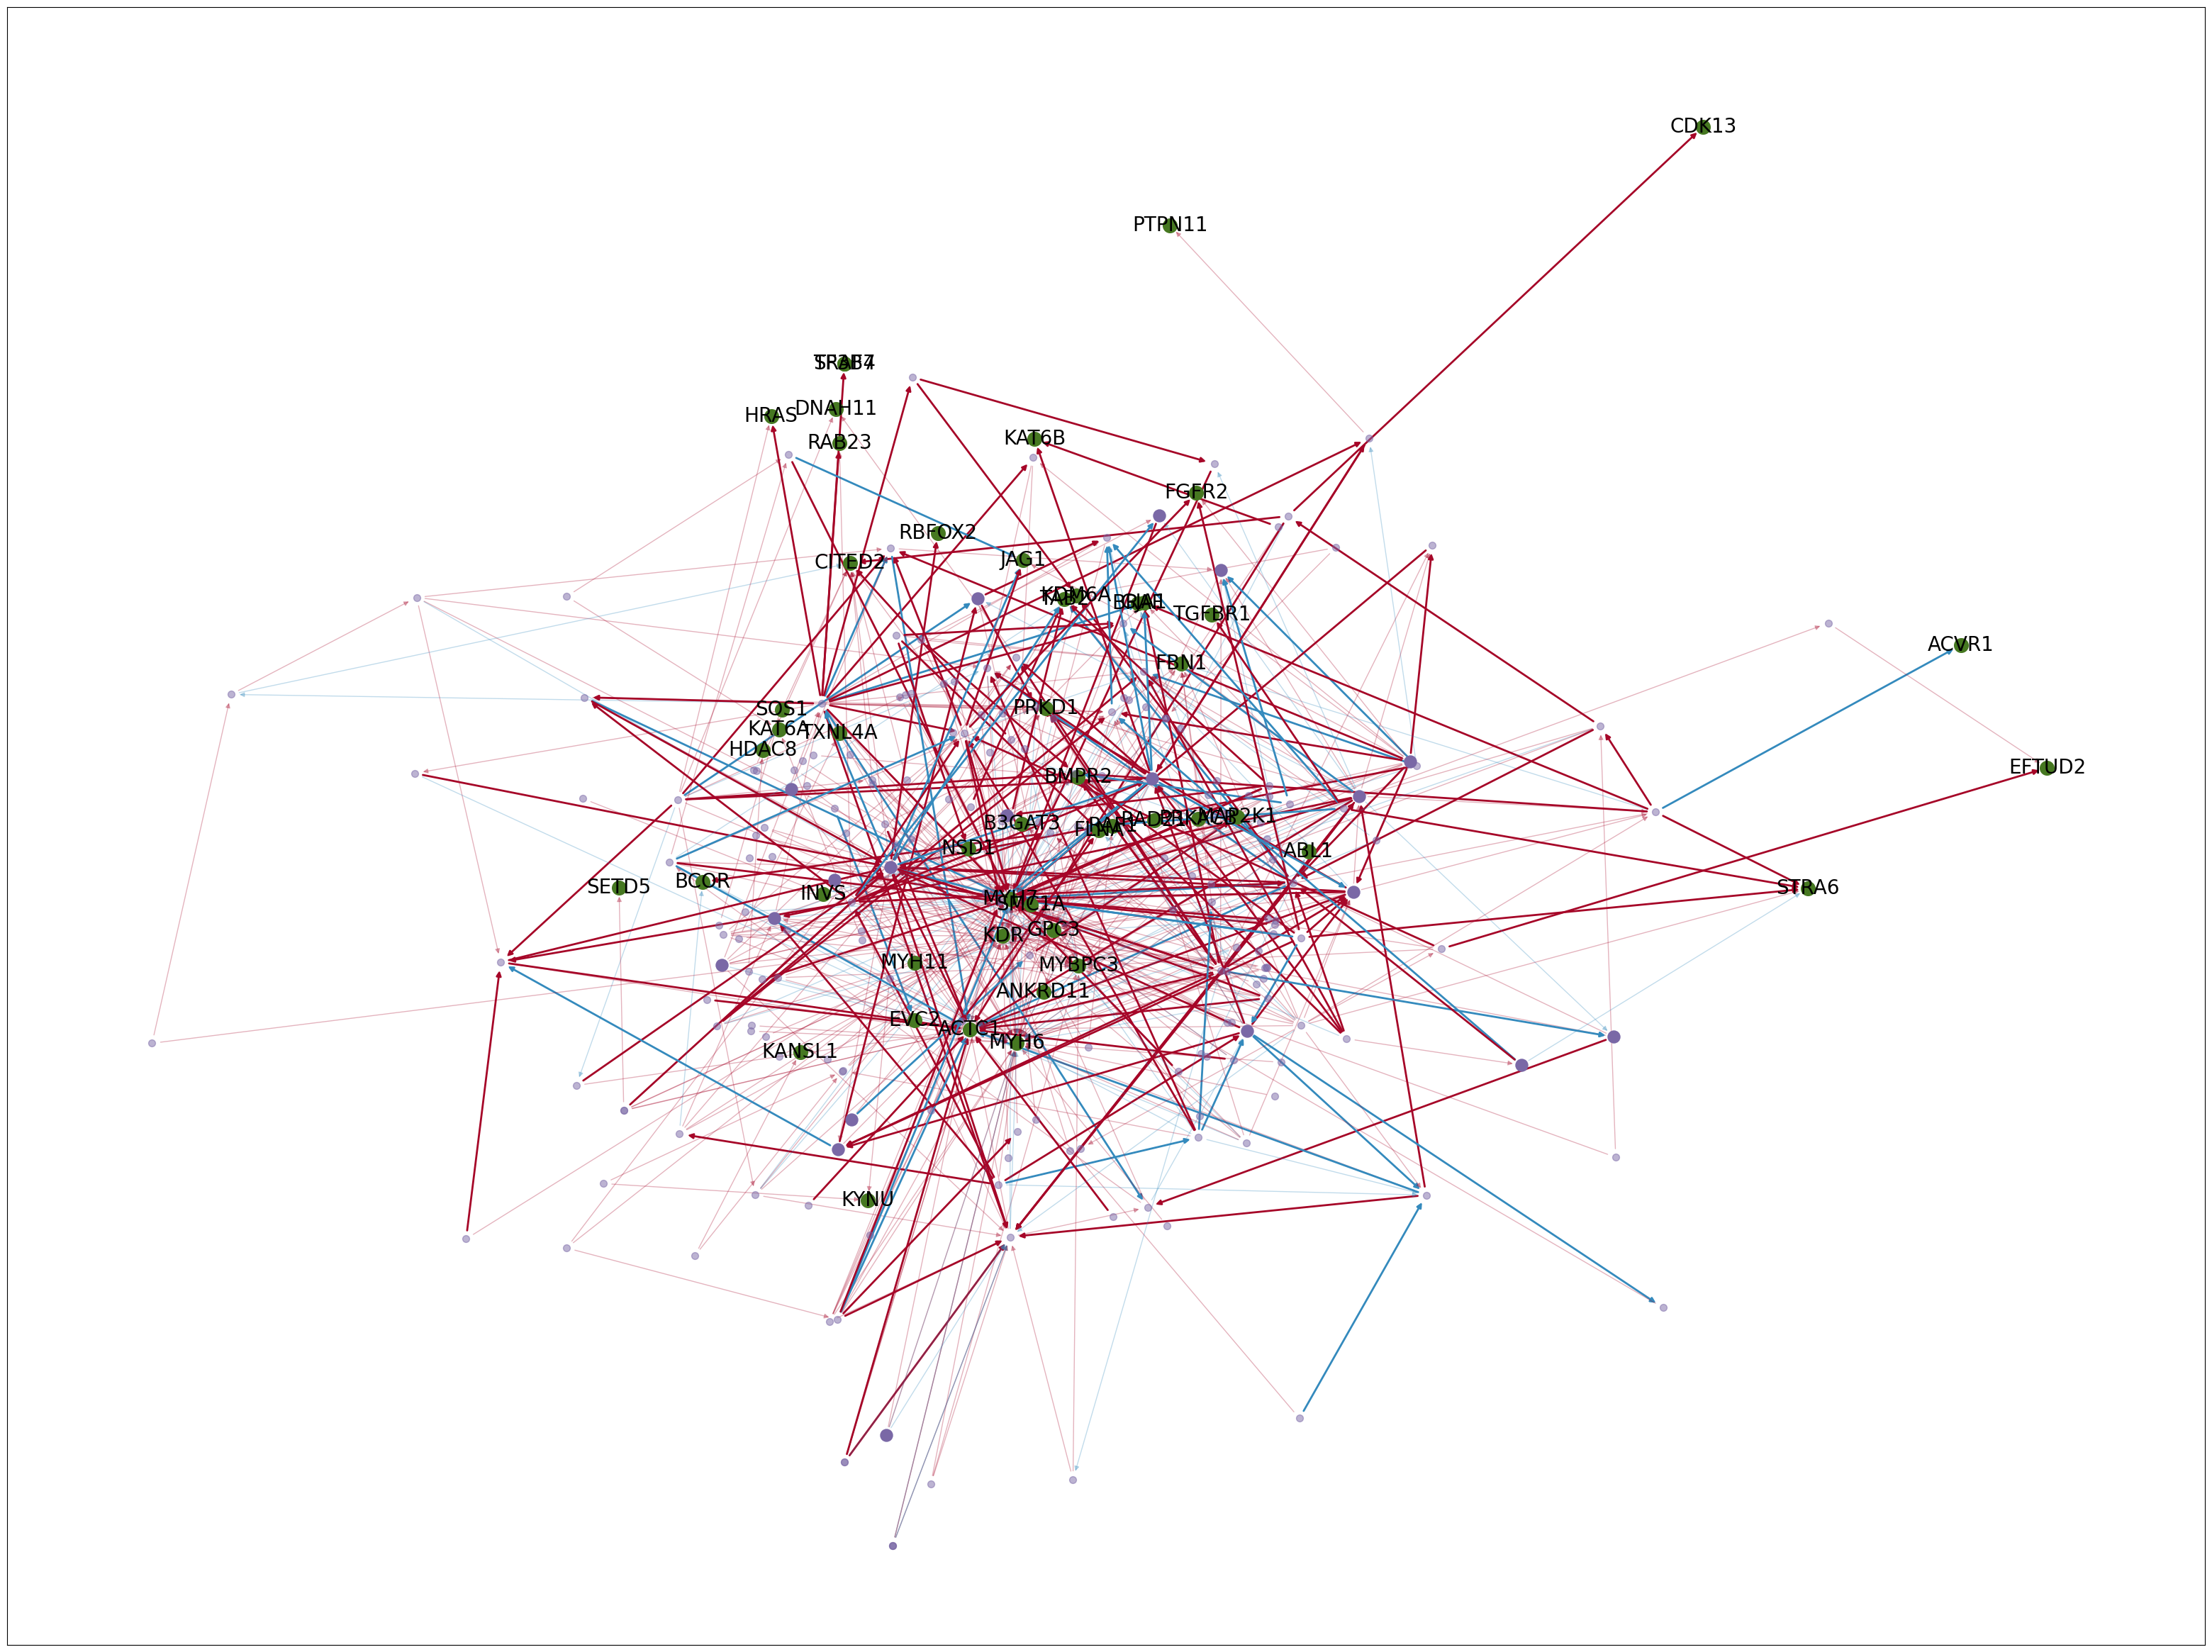

In [108]:
fig, ax = plt.subplots(figsize= (40,30))

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = non_TF_CHD_nodes,
                       node_shape = 'o',
                       node_size=200, 
                       node_color='#467821', 
                       alpha=1)

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = CHD_TF_nodes,
                       node_shape = 'o',
                       node_size=150, 
                       node_color='#7A68A6', 
                       alpha=1)

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = TF_nodes,
                       node_shape = 'o',
                       node_size=50, 
                       node_color='#7A68A6',
                       alpha=0.5)

labels = {node: str(node) for node in non_TF_CHD_nodes}
nx.draw_networkx_labels(G_non_tf_chd, pos, labels, font_size=20)

for i in G_non_tf_chd.nodes():
    nx.draw_networkx_edges(G_non_tf_chd, pos,
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if e['regulation']=='down_regualte'],
                           edge_color='#348ABD', alpha=0.3)
    nx.draw_networkx_edges(G_non_tf_chd, pos,
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if e['regulation']=='up_regualte'],
                           edge_color='#A60628', alpha=0.3)
    
    nx.draw_networkx_edges(G_non_tf_chd, pos, 
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True) 
                                     if ((e['regulation']=='down_regualte') & (e['weight'] == 3))],
                           edge_color='#348ABD', alpha=1, width=2)
    nx.draw_networkx_edges(G_non_tf_chd, pos, 
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if ((e['regulation']=='up_regualte') & (e['weight'] == 3))],
                           edge_color='#A60628', alpha=1, width=2)